### Task 1

Processed 500 commits so far
Processed 1000 commits so far
Processed 1500 commits so far
Processed 2000 commits so far
Processed 2500 commits so far
Processed 3000 commits so far
Processed 3500 commits so far
Processed 4000 commits so far
Processed 4500 commits so far
Processed 5000 commits so far
Processed 5500 commits so far
Processed 6000 commits so far
Processed 6500 commits so far
Processed 7000 commits so far
Processed 7500 commits so far
Processed 8000 commits so far
Processed 8500 commits so far
Total commits processed: 8817
Files with most defects: [('src\\transformers\\modeling_utils.py', 367), ('src\\transformers\\__init__.py', 314)]
Finished processing.


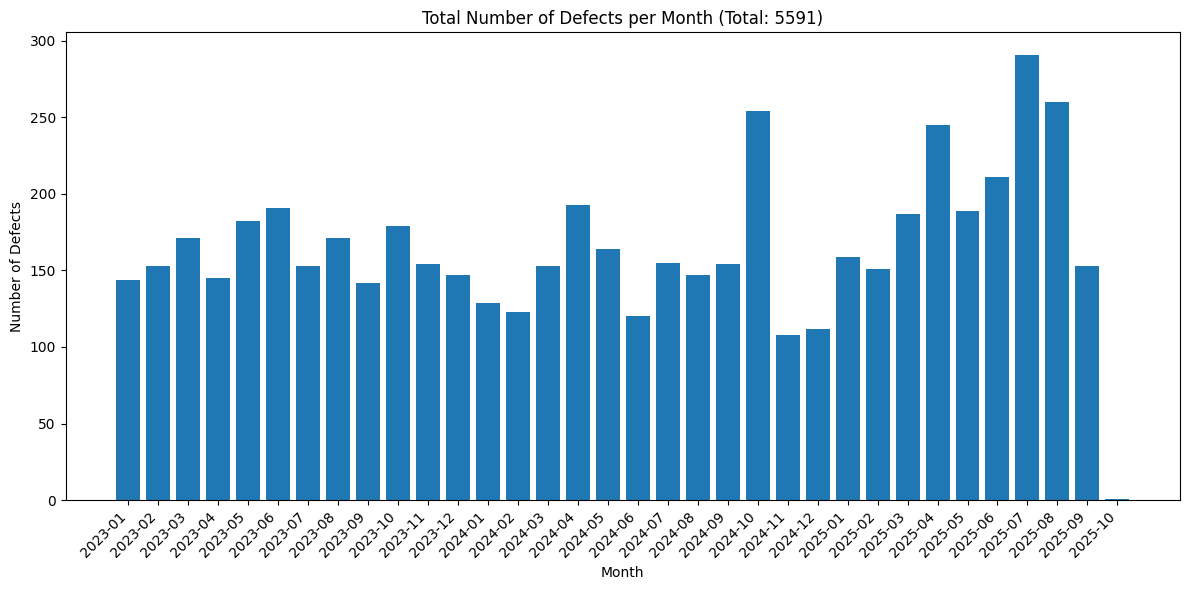

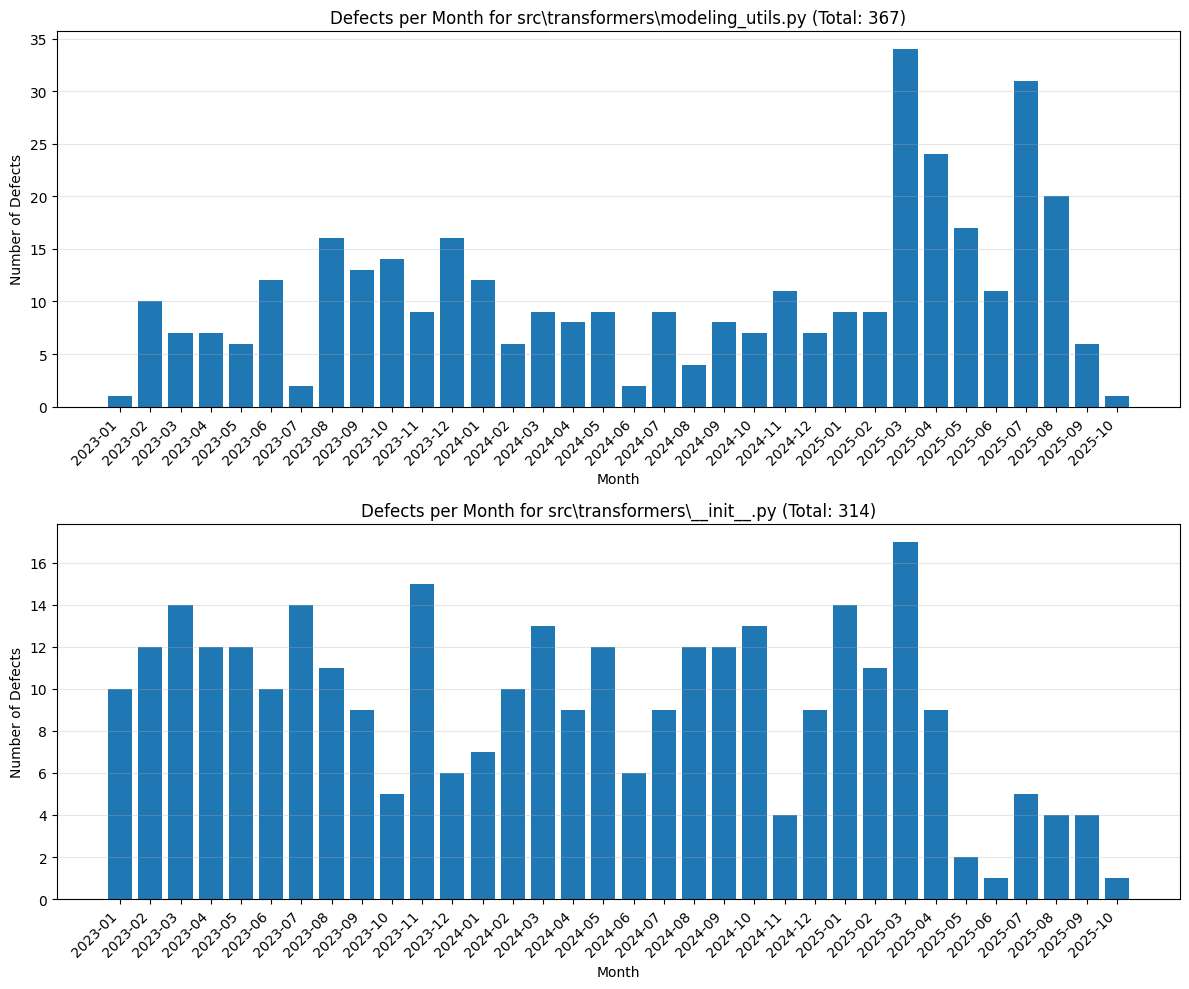

In [ ]:
from pydriller import Repository
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt


repository = "" #local URL to cloned repo, checkout tag v4.57.0 
#tag = "v4.57.0"
date = datetime(2023, 1, 1)
keywords = ['bug', 'fix', 'error', 'issue', 'bugfix', 'hotfix', 'patch']

defects_per_month = defaultdict(int)  #{(year, month): count}
defects_per_file = defaultdict(int)   #{filename: count}
count = 0
total_defects = 0
for commit in Repository(repository, since=date).traverse_commits():
    count += 1
    message = commit.msg.lower()  #ignore casing
    isKeywordPresent = any(word in message for word in keywords)

    if isKeywordPresent:
        total_defects += 1
        year_month = (commit.committer_date.year, commit.committer_date.month)
        defects_per_month[year_month] += 1

        for file in commit.modified_files:
            defects_per_file[file.new_path] += 1

    if count % 500 == 0:
        print(f"Processed {count} commits so far")

print(f"Total commits processed: {count}")

#Task 1
months = sorted(defects_per_month.keys())
defect_counts = [defects_per_month[month] for month in months]
month_labels = [f"{year}-{month:02d}" for year, month in months]

plt.figure(figsize=(12, 6))
plt.bar(range(len(months)), defect_counts)
plt.xlabel('Month')
plt.ylabel('Number of Defects')
plt.title(f'Total Number of Defects per Month (Total: {total_defects})')
plt.xticks(range(len(months)), month_labels, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('TASK1_defects_per_month.png')


#Task 2
top_2_files = sorted(defects_per_file.items(), key=lambda x: x[1], reverse=True)[:2]
file1_path, file1_count = top_2_files[0]
file2_path, file2_count = top_2_files[1]
print(f"Files with most defects: {top_2_files}")

def get_file_defects_per_month(filepath):
    file_defects_per_month = defaultdict(int)
    
    for commit in Repository(repository, since=date, filepath=filepath).traverse_commits():
        message = commit.msg.lower() #ignore casing
        isKeywordPresent = any(word in message for word in keywords)
        
        if isKeywordPresent:
            year_month = (commit.committer_date.year, commit.committer_date.month)
            file_defects_per_month[year_month] += 1
        
    return file_defects_per_month

file1_defects_per_month = get_file_defects_per_month(file1_path)
file2_defects_per_month = get_file_defects_per_month(file2_path)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
#Plot for file 1
months_file1 = sorted(file1_defects_per_month.keys())
counts_file1 = [file1_defects_per_month[month] for month in months_file1]
labels_file1 = [f"{year}-{month:02d}" for year, month in months_file1]

ax1.bar(range(len(months_file1)), counts_file1)
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Defects')
ax1.set_title(f'Defects per Month for {file1_path} (Total: {file1_count})')
ax1.set_xticks(range(len(months_file1)))
ax1.set_xticklabels(labels_file1, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

#Plot for file 2
months_file2 = sorted(file2_defects_per_month.keys())
counts_file2 = [file2_defects_per_month[month] for month in months_file2]
labels_file2 = [f"{year}-{month:02d}" for year, month in months_file2]

ax2.bar(range(len(months_file2)), counts_file2)
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Defects')
ax2.set_title(f'Defects per Month for {file2_path} (Total: {file2_count})')
ax2.set_xticks(range(len(months_file2)))
ax2.set_xticklabels(labels_file2, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('TASK1_top2_files_defects_per_month.png')

print("Finished processing.")

### Task 2

# Task 2 notes
# The metrics we select are cyclomatic comlexity (CC) and lines of code (LoC)

In [3]:
import os
from pathlib import Path
from radon.raw import analyze
from radon.complexity import cc_visit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Here we assume that the transormers repo was cloned into the parent folder
repo = Path("..")/"transformers"
repo.resolve()

WindowsPath('C:/Users/pio/Desktop/Local Code/FoSS/SoftwareEvolution/transformers')

In [4]:
# Funcitons 

def calculate_LoC_file(file_path: Path) -> int:
    file_text = file_path.read_text(encoding="utf-8")
    file_loc = analyze(file_text).loc
    return file_loc

def calculate_CC_file(file_path: Path) -> int:
    try:
        text = file_path.read_text(encoding="utf-8")
        blocks = cc_visit(text)
        return sum(b.complexity for b in blocks)
    except:
        print("error")
        return 0.0 # cant decypher file (There are only 2 errors in total)

def calculate_complexity_path(repo_path: Path) -> pd.DataFrame:
    file_data = []
    
    for path in repo_path.rglob("*.py"):
        path_length = len(path.parts)
        rel_path = path.relative_to(repo_path).parent

        file_data.append({
            "file_name": path.name,
            "parent_folder": rel_path,
            "parent_of_parent_folder": rel_path.parent,
            "LoC": calculate_LoC_file(path),
            "CC": calculate_CC_file(path)
        })


    return pd.DataFrame(file_data)

In [5]:
# Calculating CC and LoC Dataframe
df = calculate_complexity_path(repo_path=repo)

error
error


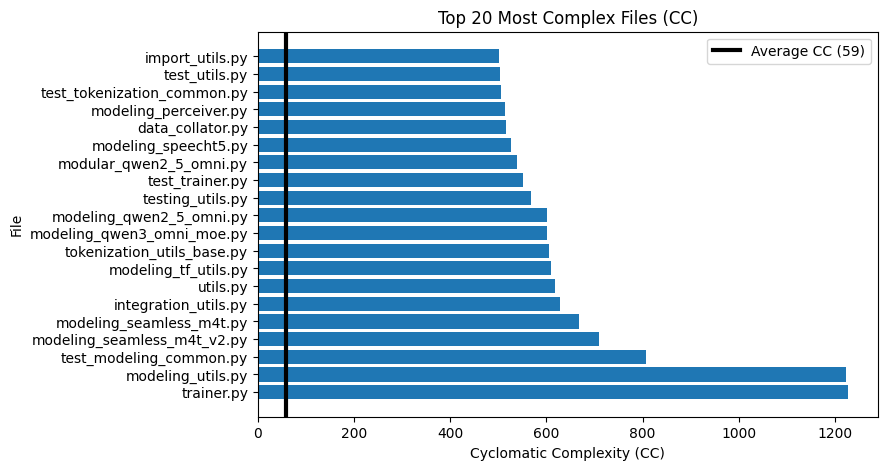

In [6]:
top20 = df.sort_values("CC", ascending=False).head(20)
average_cc = df["CC"].mean()

plt.figure(figsize=(8, 5))
plt.barh(top20["file_name"],top20["CC"],)
plt.axvline(average_cc,color="black",linewidth=3,label=f"Average CC ({average_cc:.0f})")

plt.xlabel("Cyclomatic Complexity (CC)")
plt.ylabel("File")
plt.title("Top 20 Most Complex Files (CC)")
plt.legend()
plt.show()

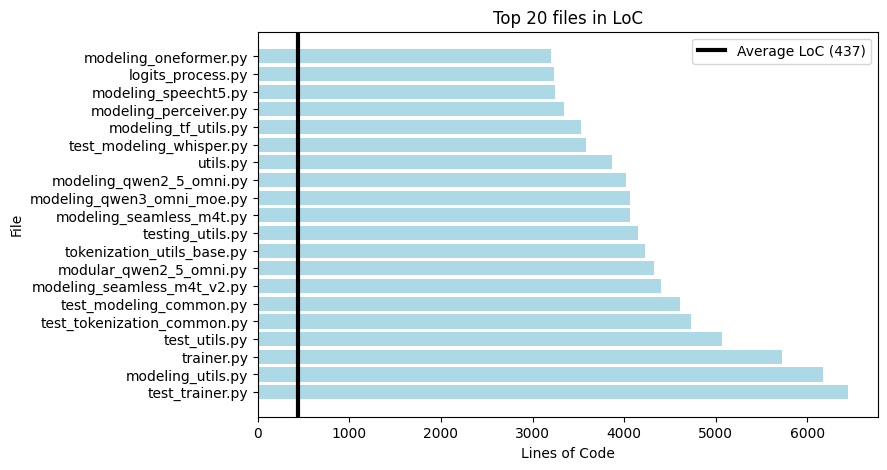

In [7]:
top20 = df.sort_values("LoC", ascending=False).head(20)
average_cc = df["LoC"].mean()

plt.figure(figsize=(8, 5))
plt.barh(top20["file_name"],top20["LoC"],color="lightblue",)
plt.axvline(average_cc,color="black",linewidth=3,label=f"Average LoC ({average_cc:.0f})")

plt.xlabel("Lines of Code")
plt.ylabel("File")
plt.title("Top 20 files in LoC")
plt.legend()
plt.show()

,parent_folder,count,LoC,CC
52,src\transformers\data,2,1114.000000,257.500000
360,src\transformers\models\qwen2_5_omni,5,1964.200000,251.600000
389,src\transformers\models\seamless_m4t_v2,3,1616.666667,237.333333
417,src\transformers\models\tapas,5,1571.800000,234.800000
368,src\transformers\models\qwen3_omni_moe,5,1697.600000,223.400000
57,src\transformers\generation,14,1315.071429,190.285714
50,src\transformers,63,1067.031746,167.095238
86,src\transformers\models\bigbird_pegasus,3,1157.666667,165.333333
235,src\transformers\models\groupvit,4,1001.750000,162.500000
277,src\transformers\models\longt5,4,1221.000000,161.000000


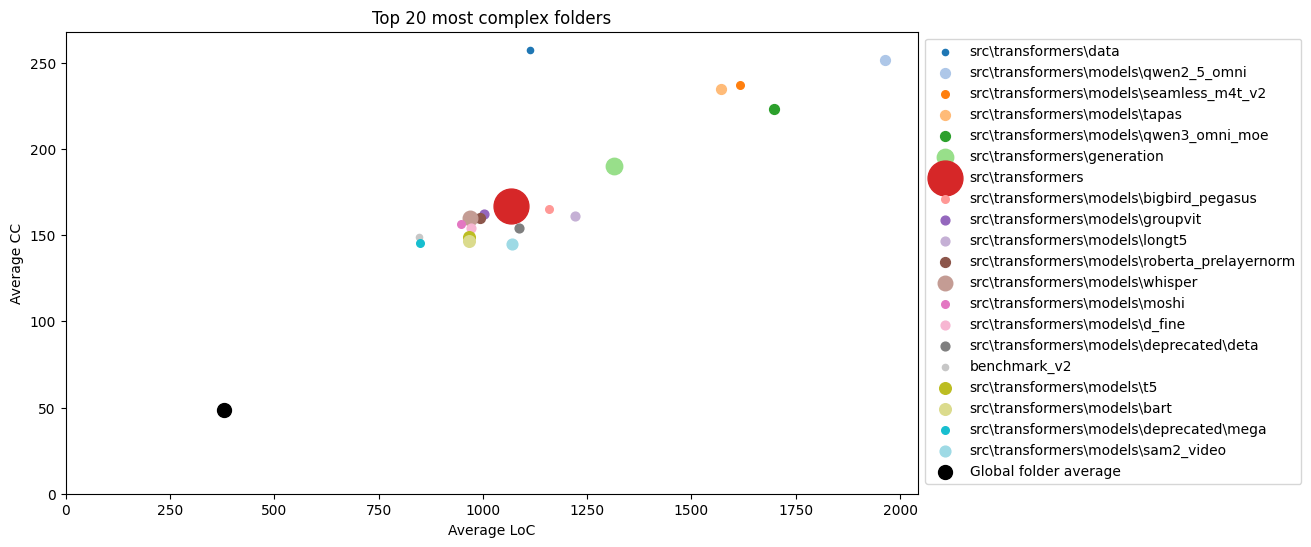

In [ ]:
df_folder_avg_data = df.groupby("parent_folder").agg(
    count=("parent_folder", "size"),
    LoC=("LoC", "mean"),
    CC=("CC","mean")
).reset_index()
top20_folders_CC = df_folder_avg_data.sort_values("CC", ascending=False).head(20)
display(top20_folders_CC.head(20))

# creating matching color to folder
categories = top20_folders_CC["parent_folder"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(categories)))
color_map = dict(zip(categories, colors))

plt.figure(figsize=(11, 6))

# plotting the 20 top folders
for _, row in top20_folders_CC.iterrows():
    current_folder = row["parent_folder"]
    plt.scatter(row["LoC"],row["CC"],color=color_map[current_folder],s=10*row["count"],label=current_folder)

plt.scatter(df_folder_avg_data["LoC"].mean(), df_folder_avg_data["CC"].mean(), color="black",s=100,label="Global folder average")

# making thie axis start at 0
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xlabel("Average LoC")
plt.ylabel("Average CC")
plt.title("Top 20 most complex folders")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()
